In [1]:
import pandas as pd
import torch
from transformers import pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_csv('../Dataset/test_set.csv')

# Handle missing values
df['komentar_super_clean'] = df['komentar_super_clean'].fillna("")

In [3]:
if torch.cuda.is_available():
    device_id = 0
    print("Menggunakan GPU (CUDA)")
elif torch.backends.mps.is_available():
    device_id = 0  
    print("Menggunakan Mac GPU (MPS)")
else:
    device_id = -1
    print("Menggunakan CPU")

Menggunakan Mac GPU (MPS)


In [4]:
print("Memuat model IndoBERT")
classifier = pipeline(
    "text-classification",
    model="../indobert_base_judol_final",
    tokenizer="../indobert_base_judol_final",
    device=device_id
)

Memuat model IndoBERT


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 270.25it/s, Materializing param=classifier.weight]                                      


In [5]:
print("Memulai prediksi (batch)...")

texts = df['komentar_super_clean'].astype(str).str[:512].tolist()

results = classifier(
    texts,
    batch_size=16,
    truncation=True
)

df['prediksi_indobert'] = [
    1 if r['label'] == 'LABEL_1' else 0 for r in results
]

df['confidence'] = [r['score'] for r in results]


Memulai prediksi (batch)...


In [6]:
print("\nEvaluasi model IndoBERT:")

y_true = df['label']
y_pred = df['prediksi_indobert']

acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, zero_division=0)
rec = recall_score(y_true, y_pred, zero_division=0)
f1 = f1_score(y_true, y_pred, zero_division=0)

print("\n--- INDOBERT BASE ---")
print(f"Akurasi  : {acc*100:.2f}%")
print(f"Precision: {prec*100:.2f}%")
print(f"Recall   : {rec*100:.2f}%")
print(f"F1 Score : {f1*100:.2f}%")


Evaluasi model IndoBERT:

--- INDOBERT BASE ---
Akurasi  : 99.41%
Precision: 99.64%
Recall   : 98.93%
F1 Score : 99.28%



Menampilkan confusion matrix...


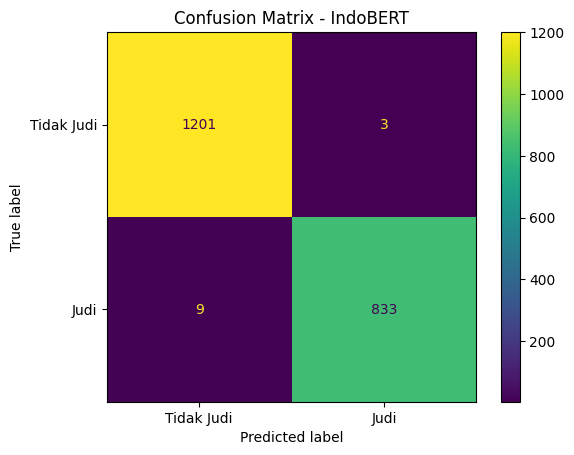

In [9]:
print("\nMenampilkan confusion matrix...")

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Tidak Judi", "Judi"]
)

disp.plot()
plt.title("Confusion Matrix - IndoBERT")

plt.savefig("confusion_matrix_indobert.png", dpi=300, bbox_inches='tight')

plt.show()

In [8]:
output_file = "../Prediction Results/hasil_indobert_final.csv"
df.to_csv(output_file, index=False)

print(f"\nHasil disimpan ke: {output_file}")

print("\nSample hasil:")
print(df[['komentar_super_clean', 'label', 'prediksi_indobert', 'confidence']].head(10))


Hasil disimpan ke: ../Prediction Results/hasil_indobert_final.csv

Sample hasil:
                                komentar_super_clean  label  \
0                  apa beda hasil kerja vs nepotisme      0   
1  pak wakil cobain deh live d bigo cakep tuh bia...      0   
2  bro kita lihat bagaimana buzzer mengcounter op...      0   
3                                           kamu ori      0   
4  jangan sok edukasi kalai kerja masih dibantuin...      0   
5  jakpot besar bikin aku makin percaya sama kebe...      1   
6                                      iyain aja dah      0   
7  bro alexis17 turnamen gede nih hadiahnya bisni...      1   
8   gila sih gak bisa move on dari serunya j 2 0 0 m      1   
9                      gas bg ziko modif aerox turbo      0   

   prediksi_indobert  confidence  
0                  0    0.999910  
1                  0    0.999855  
2                  0    0.999907  
3                  0    0.999866  
4                  0    0.999910  
5             